# HEART DISEASE PREDICTION EDA AND LOGISTIC REGRESSION MODEL

## IMPORTANT LIBRARIES AND DATA UNDERSTANDING

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [3]:
heart_disease_url = "heart_disease_uci.csv"

In [4]:
heart_df = pd.read_csv(heart_disease_url)

In [5]:
heart_df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Column Renaming for better Readability**

In [6]:
heart_df = heart_df.rename(columns={
    "id": "patient_id",
    "age": "age",
    "origin": "study_origin",
    "sex": "gender",
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar",
    "restecg": "resting_ecg",
    "thalch": "max_heart_rate",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "major_vessels",
    "thal": "thalassemia",
    "num": "heart_disease"
})

In [7]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               920 non-null    int64  
 1   age                      920 non-null    int64  
 2   gender                   920 non-null    object 
 3   dataset                  920 non-null    object 
 4   chest_pain_type          920 non-null    object 
 5   resting_blood_pressure   861 non-null    float64
 6   cholesterol              890 non-null    float64
 7   fasting_blood_sugar      830 non-null    object 
 8   resting_ecg              918 non-null    object 
 9   max_heart_rate           865 non-null    float64
 10  exercise_induced_angina  865 non-null    object 
 11  st_depression            858 non-null    float64
 12  st_slope                 611 non-null    object 
 13  major_vessels            309 non-null    float64
 14  thalassemia              4

**Converting Heart Disease column to 0s and 1s for Classification**

In [8]:
heart_df["heart_disease"] = (heart_df["heart_disease"] > 0).astype(int)

## EDA

In [9]:
fig = px.histogram(heart_df, x='age', marginal='box', color="heart_disease" ,nbins=49, title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [10]:
heart_df["gender"].value_counts()

gender
Male      726
Female    194
Name: count, dtype: int64

**Encoding Binary Categories**

In [11]:
gender_codes = {'Male' : 1, 'Female' : 0}
heart_df["gender"]= heart_df["gender"].map(gender_codes)

In [12]:
px.histogram(heart_df, x = 'gender', color = 'heart_disease' , title= "Heart Diseases wrt Gender")

In [13]:
px.histogram(heart_df,x= "dataset",color="heart_disease", title="Places of Data") 

In [14]:
heart_df["chest_pain_type"].value_counts()

chest_pain_type
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [15]:
px.histogram(heart_df,x= "chest_pain_type",color="heart_disease", title="Chest Pain with Heart Disease") 

In [16]:
blood_sugar_code = {True: 1,False: 0}
heart_df["fasting_blood_sugar"] = heart_df["fasting_blood_sugar"].map(blood_sugar_code)

In [17]:
heart_df["fasting_blood_sugar"].value_counts()

fasting_blood_sugar
0.0    692
1.0    138
Name: count, dtype: int64

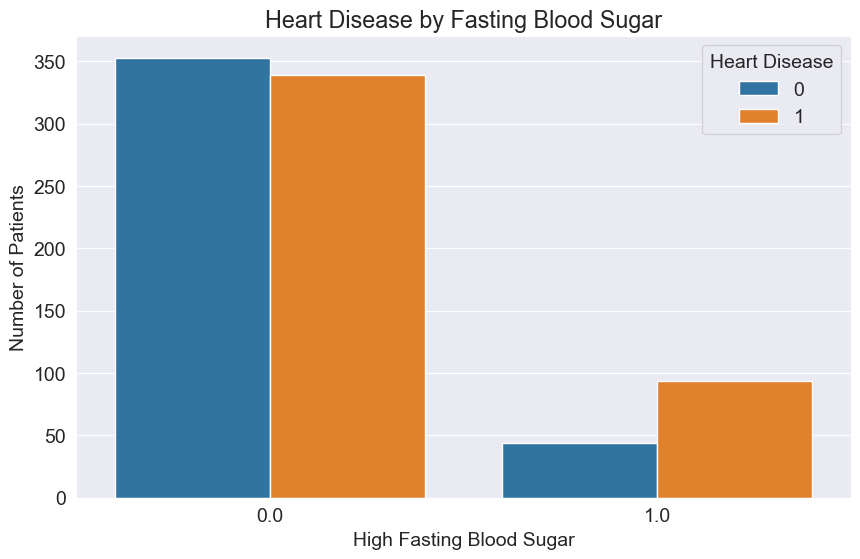

In [18]:
sns.countplot(
    data=heart_df,
    x="fasting_blood_sugar",
    hue="heart_disease"
)
plt.title("Heart Disease by Fasting Blood Sugar")
plt.xlabel("High Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [19]:
heart_df["resting_ecg"].value_counts()

resting_ecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

In [20]:
px.histogram(heart_df, x = "resting_ecg" , color = "heart_disease", title = "Resting ecg w.r.t Heart Disease")

In [21]:
px.histogram(heart_df, x = "st_depression" ,nbins = 20, color = "heart_disease", title = "Depression w.r.t Heart Disease")

In [22]:
heart_df["st_slope"].value_counts()

st_slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

In [23]:
px.histogram(heart_df, x = "st_slope" , color = "heart_disease")

## HANDLING MISSING VALUES

In [24]:
heart_df["resting_blood_pressure"] = heart_df["resting_blood_pressure"].fillna(heart_df["resting_blood_pressure"].median())
heart_df["cholesterol"] = heart_df["cholesterol"].fillna(heart_df["cholesterol"].median())

In [25]:
heart_df["fasting_blood_sugar"] = heart_df["fasting_blood_sugar"].fillna(heart_df["fasting_blood_sugar"].mode()[0])

In [26]:
heart_df = heart_df.dropna(subset=["resting_ecg"])

In [27]:
heart_df["max_heart_rate"] = heart_df["max_heart_rate"].fillna(heart_df["max_heart_rate"].median())

In [28]:
exercise_codes = {True : 1 , False : 0}
heart_df["exercise_induced_angina"] = heart_df["exercise_induced_angina"].map(exercise_codes)

In [29]:
heart_df["exercise_induced_angina"].value_counts()

exercise_induced_angina
0.0    526
1.0    337
Name: count, dtype: int64

In [30]:
heart_df["exercise_induced_angina"] = heart_df["exercise_induced_angina"].fillna(heart_df["exercise_induced_angina"].mode()[0])

In [31]:
heart_df["st_depression"] = heart_df["st_depression"].fillna(heart_df["st_depression"].median())

In [32]:
heart_df["st_slope"] = heart_df["st_slope"].fillna("Unknown")

In [33]:
heart_df = heart_df.drop(columns= ["patient_id","major_vessels","thalassemia","dataset"])

In [34]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      918 non-null    int64  
 1   gender                   918 non-null    int64  
 2   chest_pain_type          918 non-null    object 
 3   resting_blood_pressure   918 non-null    float64
 4   cholesterol              918 non-null    float64
 5   fasting_blood_sugar      918 non-null    float64
 6   resting_ecg              918 non-null    object 
 7   max_heart_rate           918 non-null    float64
 8   exercise_induced_angina  918 non-null    float64
 9   st_depression            918 non-null    float64
 10  st_slope                 918 non-null    object 
 11  heart_disease            918 non-null    int64  
dtypes: float64(6), int64(3), object(3)
memory usage: 93.2+ KB


In [35]:
heart_df.describe()

,age,gender,resting_blood_pressure,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_induced_angina,st_depression,heart_disease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.530501,0.788671,132.005447,200.022876,0.150327,137.676471,0.367102,0.854902,0.552288
std,9.412783,0.408474,18.460987,108.913893,0.357586,25.166813,0.482278,1.058606,0.497530
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,47.000000,1.000000,120.000000,178.250000,0.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,140.000000,0.000000,0.500000,1.000000
75%,60.000000,1.000000,140.000000,266.750000,0.000000,156.000000,1.000000,1.500000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000


In [36]:
heart_df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,heart_disease
0,63,1,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0
1,67,1,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,1
2,67,1,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,1
3,37,1,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0
4,41,0,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0


In [37]:
heart_df.columns

Index(['age', 'gender', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'st_slope',
       'heart_disease'],
      dtype='object')

## ENCODING CATEGORICAL DATA

In [38]:
from sklearn import preprocessing
p_enc = preprocessing.OneHotEncoder()
p_enc.fit(heart_df[["chest_pain_type"]])
p_enc.categories_

[array(['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina'],
       dtype=object)]

In [39]:
pain_enc = p_enc.transform(heart_df[["chest_pain_type"]]).toarray()
pain_enc

array([[0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]], shape=(918, 4))

In [40]:
heart_df[["asymptomatic","atypical angina","non-anginal","typical angina"]]= pain_enc

In [41]:
e_enc = preprocessing.OneHotEncoder()
e_enc.fit(heart_df[["resting_ecg"]])
e_enc.categories_

[array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)]

In [42]:
ecg_enc = e_enc.transform(heart_df[["resting_ecg"]]).toarray()

In [43]:
heart_df[["lv hypertrophy", "normal", "st-t abnormality"]] = ecg_enc

In [44]:
s_enc = preprocessing.OneHotEncoder()
s_enc.fit(heart_df[["st_slope"]])
s_enc.categories_

[array(['Unknown', 'downsloping', 'flat', 'upsloping'], dtype=object)]

In [45]:
slope_enc = s_enc.transform(heart_df[["st_slope"]]).toarray()

In [46]:
heart_df [["Unknown","downsloping","flat","upsloping"]] = slope_enc

In [47]:
heart_df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,...,atypical angina,non-anginal,typical angina,lv hypertrophy,normal,st-t abnormality,Unknown,downsloping,flat,upsloping
0,63,1,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,67,1,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,67,1,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,37,1,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,41,0,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


**Dropping encoded columns**

In [48]:
heart_df = heart_df.drop(columns = ["chest_pain_type","resting_ecg","st_slope"])

In [49]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      918 non-null    int64  
 1   gender                   918 non-null    int64  
 2   resting_blood_pressure   918 non-null    float64
 3   cholesterol              918 non-null    float64
 4   fasting_blood_sugar      918 non-null    float64
 5   max_heart_rate           918 non-null    float64
 6   exercise_induced_angina  918 non-null    float64
 7   st_depression            918 non-null    float64
 8   heart_disease            918 non-null    int64  
 9   asymptomatic             918 non-null    float64
 10  atypical angina          918 non-null    float64
 11  non-anginal              918 non-null    float64
 12  typical angina           918 non-null    float64
 13  lv hypertrophy           918 non-null    float64
 14  normal                   918 no

## SCALING THE DATA

In [50]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heart_df = pd.DataFrame(
    scaler.fit_transform(heart_df),
    columns=heart_df.columns
)

In [51]:
heart_df.head(10)

,age,gender,resting_blood_pressure,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_induced_angina,st_depression,heart_disease,asymptomatic,atypical angina,non-anginal,typical angina,lv hypertrophy,normal,st-t abnormality,Unknown,downsloping,flat,upsloping
0,0.714286,1.0,0.725,0.386401,1.0,0.633803,0.0,0.556818,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.795918,1.0,0.800,0.474295,0.0,0.338028,1.0,0.465909,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.795918,1.0,0.600,0.379768,0.0,0.485915,1.0,0.590909,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.183673,1.0,0.650,0.414594,0.0,0.894366,0.0,0.693182,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.265306,0.0,0.650,0.338308,0.0,0.788732,0.0,0.454545,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.571429,1.0,0.600,0.391376,0.0,0.830986,0.0,0.386364,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
6,0.693878,0.0,0.700,0.444444,0.0,0.704225,0.0,0.704545,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,0.591837,0.0,0.600,0.587065,0.0,0.725352,1.0,0.363636,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8,0.714286,1.0,0.650,0.421227,0.0,0.612676,0.0,0.454545,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.510204,1.0,0.700,0.336650,1.0,0.669014,1.0,0.647727,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## EXPORTING CSV TO TRAIN MODEL IN ANOTHER FILE

In [52]:
heart_df.to_csv("heart_disease_cleaned.csv", index=False)